<a href="https://colab.research.google.com/github/zopvan/mlStrkanalystRF/blob/main/RF_UTS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
import seaborn as sns
import matplotlib.pyplot as plt
from google.colab import drive
from imblearn.over_sampling import SMOTE
from sklearn.dummy import DummyClassifier

In [ ]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!ls /content/drive/MyDrive/UTS_machine_learning/RF/

brain_stroke.csv  SVM_UTS.ipynb


In [ ]:
file_path = '/content/drive/MyDrive/UTS_machine_learning/RF/brain_stroke.csv'

try:
    df = pd.read_csv(file_path)
    print("Dataset berhasil dimuat!")
    print(f"Jumlah Baris: {df.shape[0]}, Jumlah Kolom: {df.shape[1]}")
except FileNotFoundError:
    print("File tidak ditemukan. Pastikan path sudah benar.")
    raise SystemExit

Dataset berhasil dimuat!
Jumlah Baris: 4981, Jumlah Kolom: 11


In [ ]:
df.shape

(4981, 11)

In [ ]:
df.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
2,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
3,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
4,Male,81.0,0,0,Yes,Private,Urban,186.21,29.0,formerly smoked,1


### Data Auditing

In [ ]:
# 1. Jumlah Baris dan Kolom
print(f"Bentuk dataset: {df.shape[0]} baris, {df.shape[1]} kolom")

Bentuk dataset: 4981 baris, 11 kolom


In [ ]:
# 2. Tipe Data
print("\n--- Tipe Data ---")
print(df.dtypes)


--- Tipe Data ---
gender                object
age                  float64
hypertension           int64
heart_disease          int64
ever_married          object
work_type             object
Residence_type        object
avg_glucose_level    float64
bmi                  float64
smoking_status        object
stroke                 int64
dtype: object


In [ ]:
# 3 & 7. Jumlah Kelas Target dan Distribusi Kelas
print("\n--- Distribusi Kelas Target (Stroke) ---")
print(df['stroke'].value_counts())


--- Distribusi Kelas Target (Stroke) ---
stroke
0    4733
1     248
Name: count, dtype: int64


In [ ]:
# 4. Deteksi Missing Values
print("\n--- Missing Value per Kolom ---")
print(df.isnull().sum())


--- Missing Value per Kolom ---
gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64


In [ ]:
# 5. Deteksi Duplikat
print(f"\n--- Jumlah Baris Duplikat: {df.duplicated().sum()} ---")


--- Jumlah Baris Duplikat: 0 ---


In [ ]:
# 6. Deteksi Outlier (menggunakan aturan IQR)
num_cols = ['age', 'avg_glucose_level', 'bmi']
print("\n--- Deteksi Outlier ---")
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = ((df[col] < (Q1 - 1.5 * IQR)) | (df[col] > (Q3 + 1.5 * IQR))).sum()
    print(f"Jumlah outlier pada atribut {col}: {outliers}")


--- Deteksi Outlier ---
Jumlah outlier pada atribut age: 0
Jumlah outlier pada atribut avg_glucose_level: 602
Jumlah outlier pada atribut bmi: 43


### Data Preprocessing

In [ ]:
# --- A. PENGHAPUSAN DUPLIKAT ---
# Menghapus baris yang identik
df.drop_duplicates(inplace=True)

In [ ]:
# --- B. IMPUTASI (Jika ada missing value) ---
# Kolom numerik diisi dengan Median
df['bmi'].fillna(df['bmi'].median(), inplace=True)

/tmp/ipykernel_9715/1143771137.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['bmi'].fillna(df['bmi'].median(), inplace=True)


In [ ]:
# --- C. STRATEGI OUTLIER (Winsorization/Capping) ---
# Membatasi nilai ekstrim agar tidak merusak model KNN/SVM
def cap_outliers(data, col):
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    data[col] = np.where(data[col] < lower_bound, lower_bound, data[col])
    data[col] = np.where(data[col] > upper_bound, upper_bound, data[col])

cap_outliers(df, 'avg_glucose_level')
cap_outliers(df, 'bmi')

In [ ]:
X = df.drop('stroke', axis=1)
y = df['stroke']

# Encoding Target (Label Encoding)
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Encoding Fitur Kategorikal (One-Hot Encoding)
X_encoded = pd.get_dummies(X, drop_first=True)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y_encoded, test_size=0.3, random_state=42)

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
print("\nMenerapkan SMOTE untuk menyeimbangkan data training...")
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train_scaled, y_train)

print("\nMelatih model Random Forest dengan data yang telah di-SMOTE dan bobot kelas seimbang...")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_model.fit(X_train_res, y_train_res)


Menerapkan SMOTE untuk menyeimbangkan data training...

Melatih model Random Forest dengan data yang telah di-SMOTE dan bobot kelas seimbang...


RandomForestClassifier(class_weight='balanced', random_state=42)

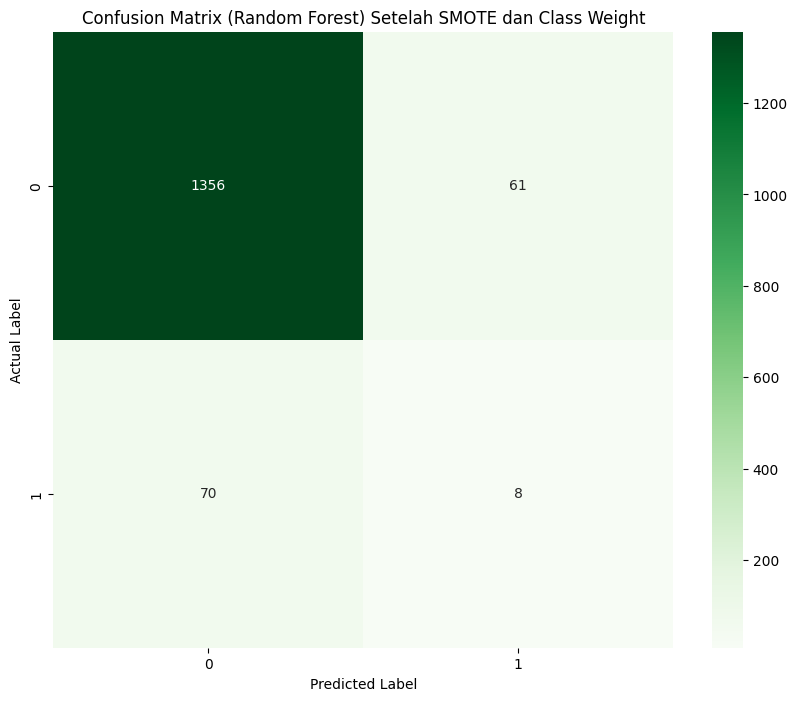

In [ ]:
y_pred_rf = rf_model.predict(X_test_scaled)
cm_rf = confusion_matrix(y_test, y_pred_rf)
class_names = le.classes_
cm_df_rf = pd.DataFrame(cm_rf, index=class_names, columns=class_names)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_df_rf, annot=True, fmt='g', cmap='Greens')
plt.title('Confusion Matrix (Random Forest) Setelah SMOTE dan Class Weight')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

In [ ]:
y_pred_rf = rf_model.predict(X_test_scaled)

accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"\nAkurasi Model Random Forest (dengan SMOTE & Class Weight): {accuracy_rf * 100:.2f}%")

# Baseline menggunakan Random Forest tanpa SMOTE atau class_weight
X_tr_base, X_te_base, y_tr_base, y_te_base = train_test_split(X_encoded, y_encoded, test_size=0.3, stratify=y_encoded, random_state=42)

rf_baseline_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_baseline_model.fit(X_tr_base, y_tr_base)
y_pred_rf_baseline = rf_baseline_model.predict(X_te_base)

print("\n--- Laporan Evaluasi Baseline (Random Forest tanpa SMOTE/Class Weight) ---")
print(classification_report(y_te_base, y_pred_rf_baseline, zero_division=0))
print("Kesimpulan: Model eksperimen utama (dengan SMOTE & Class Weight) wajib melampaui metrik ini, terutama pada recall untuk kelas target.")


Akurasi Model Random Forest (dengan SMOTE & Class Weight): 91.24%

--- Laporan Evaluasi Baseline (Random Forest tanpa SMOTE/Class Weight) ---
              precision    recall  f1-score   support

           0       0.95      1.00      0.97      1421
           1       0.33      0.01      0.03        74

    accuracy                           0.95      1495
   macro avg       0.64      0.51      0.50      1495
weighted avg       0.92      0.95      0.93      1495

Kesimpulan: Model eksperimen utama (dengan SMOTE & Class Weight) wajib melampaui metrik ini, terutama pada recall untuk kelas target.


In [ ]:
new_data = pd.DataFrame([
    {
        'gender': 'Male',
        'age': 70.0,
        'hypertension': 1,
        'heart_disease': 0,
        'ever_married': 'Yes',
        'work_type': 'Private',
        'Residence_type': 'Urban',
        'avg_glucose_level': 150.0,
        'bmi': 30.0,
        'smoking_status': 'formerly smoked'
    },
    {
        'gender': 'Female',
        'age': 35.0,
        'hypertension': 0,
        'heart_disease': 0,
        'ever_married': 'Yes',
        'work_type': 'Govt_job',
        'Residence_type': 'Rural',
        'avg_glucose_level': 90.0,
        'bmi': 22.0,
        'smoking_status': 'never smoked'
    }
])


new_data_encoded = pd.get_dummies(new_data, drop_first=True)


missing_cols = set(X_encoded.columns) - set(new_data_encoded.columns)
for c in missing_cols:
    new_data_encoded[c] = 0
new_data_encoded = new_data_encoded[X_encoded.columns]


new_data_scaled = scaler.transform(new_data_encoded)


new_predictions_encoded = rf_model.predict(new_data_scaled)


new_predictions_labels = le.inverse_transform(new_predictions_encoded)

print("\nData Baru Sebelum Encoding dan Scaling:")
display(new_data)

print("\nHasil Prediksi untuk Data Baru:")
for i, prediction in enumerate(new_predictions_labels):
    print(f"Data Baru {i+1}: {prediction}")


Data Baru Sebelum Encoding dan Scaling:


,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status
0,Male,70.0,1,0,Yes,Private,Urban,150.0,30.0,formerly smoked
1,Female,35.0,0,0,Yes,Govt_job,Rural,90.0,22.0,never smoked



Hasil Prediksi untuk Data Baru:
Data Baru 1: 0
Data Baru 2: 0


In [ ]:
import gradio as gr
import pandas as pd
import numpy as np

def predict_stroke(gender, age, hypertension, heart_disease, ever_married, work_type, Residence_type, avg_glucose_level, bmi, smoking_status):
    # 1. Mapping Input Bahasa Indonesia ke Nilai Asli Dataset
    maps = {
        "gender": {"Laki-laki": "Male", "Perempuan": "Female"},
        "ever_married": {"Ya": "Yes", "Tidak": "No"},
        "work_type": {"Swasta": "Private", "Wiraswasta": "Self-employed", "Pemerintah": "Govt_job", "Anak-anak": "children", "Tidak Pernah Bekerja": "Never_worked"},
        "residence": {"Perkotaan": "Urban", "Pedesaan": "Rural"},
        "smoking": {"Pernah Merokok": "formerly smoked", "Tidak Pernah Merokok": "never smoked", "Merokok": "smokes", "Tidak Diketahui": "Unknown"}
    }

    # 2. Siapkan Dataframe Input (Sesuai kolom asli sebelum encoding)
    data = {
        'gender': maps["gender"][gender],
        'age': age,
        'hypertension': 1 if hypertension == "Ya" else 0,
        'heart_disease': 1 if heart_disease == "Ya" else 0,
        'ever_married': maps["ever_married"][ever_married],
        'work_type': maps["work_type"][work_type],
        'Residence_type': maps["residence"][Residence_type],
        'avg_glucose_level': avg_glucose_level,
        'bmi': bmi,
        'smoking_status': maps["smoking"][smoking_status]
    }

    df_input = pd.DataFrame([data])

    # 3. Encoding yang Konsisten
    # Pastikan menggunakan kolom dari X_encoded (saat training) agar fit
    df_encoded = pd.get_dummies(df_input)

    # Menyamakan kolom dengan data training
    input_final = pd.DataFrame(columns=X_encoded.columns)
    input_final = pd.concat([input_final, df_encoded]).fillna(0)
    input_final = input_final[X_encoded.columns] # Urutan kolom harus sama persis

    # 4. Scaling & Prediksi
    input_scaled = scaler.transform(input_final)
    prediction = rf_model.predict(input_scaled)

    # 5. Output Deskriptif
    return "🚨 Risiko Stroke: TINGGI" if prediction[0] == 1 else "✅ Risiko Stroke: RENDAH"

# UI Setup
interface = gr.Interface(
    fn=predict_stroke,
    inputs=[
        gr.Dropdown(["Laki-laki", "Perempuan"], label="Jenis Kelamin"),
        gr.Slider(0, 100, label="Usia"),
        gr.Radio(["Tidak", "Ya"], label="Hipertensi"),
        gr.Radio(["Tidak", "Ya"], label="Penyakit Jantung"),
        gr.Dropdown(["Ya", "Tidak"], label="Pernah Menikah"),
        gr.Dropdown(["Swasta", "Wiraswasta", "Pemerintah", "Anak-anak", "Tidak Pernah Bekerja"], label="Jenis Pekerjaan"),
        gr.Dropdown(["Perkotaan", "Pedesaan"], label="Tipe Tempat Tinggal"),
        gr.Number(label="Gula Darah Rata-rata"),
        gr.Number(label="BMI"),
        gr.Dropdown(["Pernah Merokok", "Tidak Pernah Merokok", "Merokok", "Tidak Diketahui"], label="Status Merokok")
    ],
    outputs="text",
    title="Stroke Prediction System v2.0",
    theme="dark"
)

interface.launch()

/usr/local/lib/python3.12/dist-packages/gradio/blocks.py:1143: UserWarning: Cannot load dark. Caught Exception: Client error '404 Not Found' for url 'https://huggingface.co/api/spaces/dark' (Request ID: Root=1-69ef78fb-3744694a73b819810b28c665;6df7087b-8070-4374-991f-b4c060386387)
For more information check: https://developer.mozilla.org/en-US/docs/Web/HTTP/Status/404

Sorry, we can't find the page you are looking for.
  warnings.warn(f"Cannot load {theme}. Caught Exception: {str(e)}")


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://702eab5a9dc2d75550.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
